## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Processed Data

In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/clean_data.csv')

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully!
Shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## Feature Analysis

In [3]:
# Identify feature types
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"\nCategorical columns: {categorical_features}")

Numerical features: 41
Categorical features: 4

Categorical columns: ['proto', 'service', 'state', 'attack_cat']


In [4]:
# Separate features and target
# Update 'label' to match your dataset's target column
target_col = 'label'  # Change this if needed

if target_col not in df.columns:
    print(f"Warning: '{target_col}' not found. Available columns:")
    print(df.columns.tolist())
else:
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")

Features shape: (175341, 44)
Target shape: (175341,)


## Encode Categorical Features

In [5]:
# Encode categorical features
X_encoded = X.copy()

# Label encoding for categorical columns
label_encoders = {}
categorical_cols = X_encoded.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print(f"Encoded {len(categorical_cols)} categorical features")
print(f"All features are now numerical: {X_encoded.select_dtypes(include=[np.number]).shape[1]} features")

Encoded 4 categorical features
All features are now numerical: 44 features


In [6]:
# Encode target variable if it's categorical
if y.dtype == 'object':
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    print(f"Target classes: {le_target.classes_}")
else:
    y_encoded = y
    print(f"Target is already numerical")

Target is already numerical


## Correlation Analysis

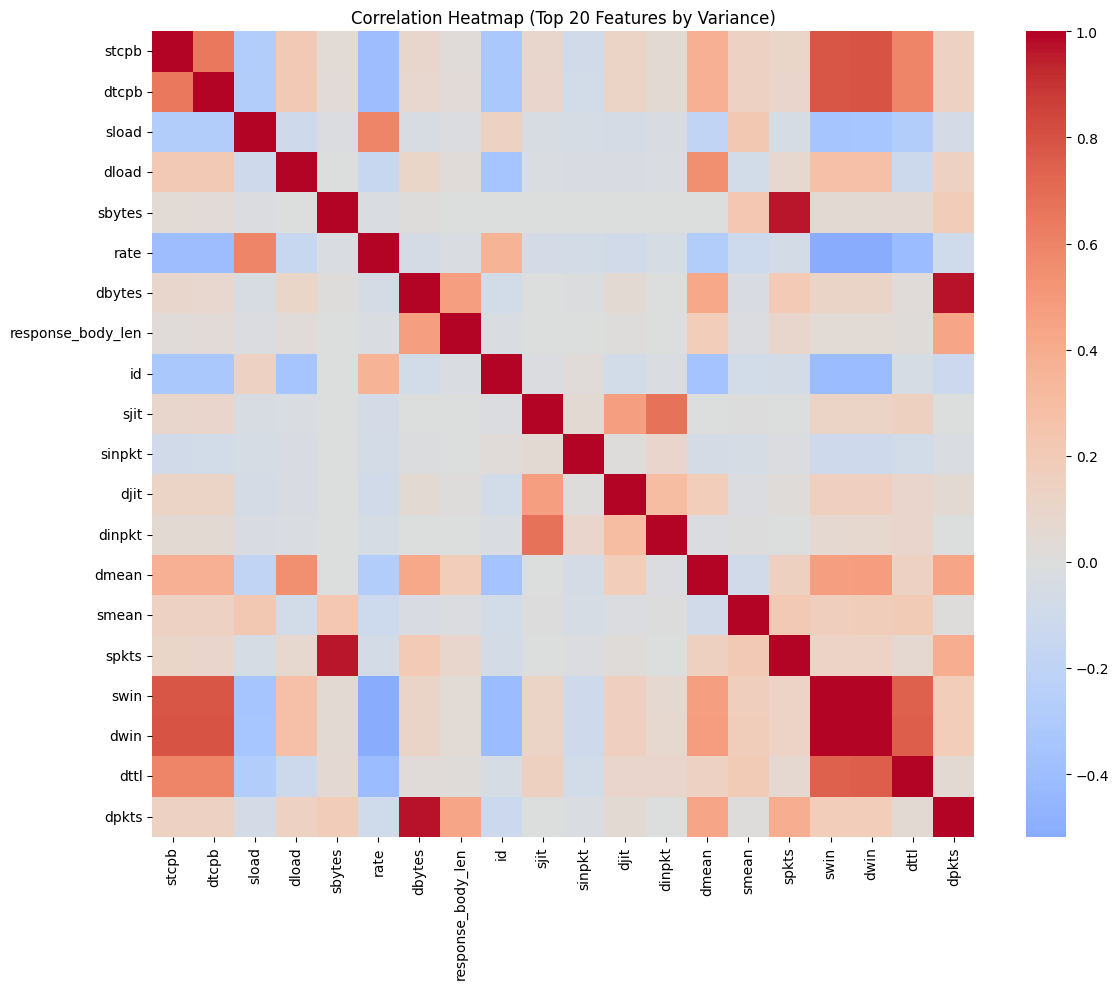

In [7]:
# Calculate correlation matrix
correlation_matrix = X_encoded.corr()

# Plot correlation heatmap (for subset of features if too many)
plt.figure(figsize=(12, 10))

# If too many features, show only top correlated ones
if len(X_encoded.columns) > 20:
    # Select top 20 features by variance
    top_features = X_encoded.var().nlargest(20).index
    sns.heatmap(X_encoded[top_features].corr(), annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap (Top 20 Features by Variance)')
else:
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [8]:
# Identify highly correlated features
threshold = 0.95
high_corr_features = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            high_corr_features.add(colname)

print(f"Features with correlation > {threshold}: {len(high_corr_features)}")
if high_corr_features:
    print(f"Highly correlated features: {high_corr_features}")

Features with correlation > 0.95: 9
Highly correlated features: {'ct_srv_dst', 'ct_ftp_cmd', 'dbytes', 'dwin', 'ct_src_dport_ltm', 'dloss', 'ct_dst_src_ltm', 'sloss', 'sbytes'}


## Feature Selection

In [9]:
# Remove highly correlated features
X_reduced = X_encoded.drop(columns=high_corr_features, errors='ignore')
print(f"Shape after removing highly correlated features: {X_reduced.shape}")

Shape after removing highly correlated features: (175341, 35)


Top 15 Most Important Features:
         Feature  Importance
34    attack_cat    0.634079
0             id    0.558861
8           sttl    0.397747
27  ct_state_ttl    0.362758
9           dttl    0.356320
7           rate    0.353480
10         sload    0.347199
1            dur    0.338964
22         smean    0.333801
23         dmean    0.312920
13        dinpkt    0.297365
11         dload    0.281003
6          dpkts    0.273333
12        sinpkt    0.247026
20        synack    0.235821


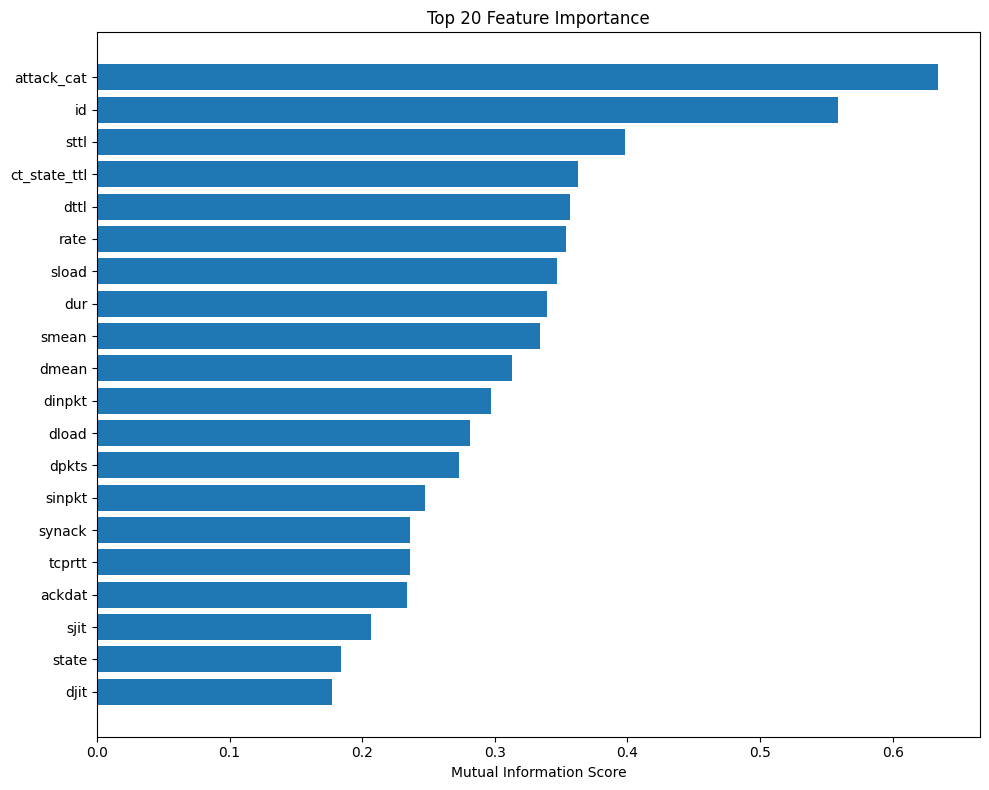

In [10]:
# Feature importance using mutual information
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_reduced, y_encoded, random_state=42)

# Create dataframe of feature importance
feature_importance = pd.DataFrame({
    'Feature': X_reduced.columns,
    'Importance': mi_scores
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_n = min(20, len(feature_importance))
plt.barh(range(top_n), feature_importance['Importance'].head(top_n))
plt.yticks(range(top_n), feature_importance['Feature'].head(top_n))
plt.xlabel('Mutual Information Score')
plt.title(f'Top {top_n} Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Feature Scaling

In [11]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

# Convert back to DataFrame
X_final = pd.DataFrame(X_scaled, columns=X_reduced.columns)

print(f"Features scaled successfully!")
print(f"Final feature shape: {X_final.shape}")
X_final.head()

Features scaled successfully!
Final feature shape: (175341, 35)


,id,dur,proto,service,state,spkts,dpkts,rate,sttl,dttl,...,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_dst_sport_ltm,is_ftp_login,ct_flw_http_mthd,ct_src_ltm,is_sm_ips_ports,attack_cat
0,-1.732041,-0.191029,0.151809,-0.702307,-0.409218,-0.104456,-0.135769,-0.576371,0.703839,1.578100,...,-0.039557,-0.775991,-1.366486,-0.645013,-0.554373,-0.118590,-0.189768,-0.715714,-0.126508,0.848024
1,-1.732021,-0.109485,0.151809,-0.702307,-0.409218,-0.046014,0.172599,-0.576345,-1.141901,1.560002,...,-0.039557,3.147666,-0.318711,-0.645013,-0.554373,-0.118590,-0.189768,-0.715714,-0.126508,0.848024
2,-1.732001,0.040699,0.151809,-0.702307,-0.409218,-0.089845,-0.026933,-0.576734,-1.141901,1.560002,...,-0.039557,-0.215468,-0.318711,-0.520827,-0.554373,-0.118590,-0.189768,-0.595543,-0.126508,0.848024
3,-1.731982,0.049729,0.151809,0.599130,-0.409218,-0.060624,-0.063212,-0.576737,-1.141901,1.560002,...,-0.039557,-0.775991,-0.318711,-0.520827,-0.554373,7.814915,-0.189768,-0.595543,-0.126508,0.848024
4,-1.731962,-0.140417,0.151809,-0.702307,-0.409218,-0.075235,-0.117630,-0.576617,0.723268,1.560002,...,-0.039557,3.147666,-0.318711,-0.520827,-0.554373,-0.118590,-0.189768,-0.595543,-0.126508,0.848024


## Save Engineered Features

In [12]:
# Combine features and target
final_data = X_final.copy()
final_data[target_col] = y_encoded

# Save to processed folder
output_path = '../data/processed/engineered_features.csv'
final_data.to_csv(output_path, index=False)

print(f"Engineered features saved to {output_path}")
print(f"Final dataset shape: {final_data.shape}")

Engineered features saved to ../data/processed/engineered_features.csv
Final dataset shape: (175341, 36)


In [ ]:
# Save feature names for later use
feature_names = X_final.columns.tolist()
print(f"Total features selected: {len(feature_names)}")
print(f"\nFeature names: {feature_names[:10]}...")  # Show first 10

Total features selected: 35

Feature names: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'rate', 'sttl', 'dttl']...


: 